# Ocean Alkalinity Enhancement (OAE) analysis

This notebook analyzes the Iceland3_MARBL_2024 OAE experiments in Hvalfjörður, focusing on how an imposed alkalinity (and associated carbon) perturbation evolves and how efficiently it removes atmospheric CO₂.

- **Model setup**: Load Iceland3 BGC diagnostic (`*_bgc_dia`), BGC tracer, and `cstar` files and regrid them to fixed depth levels.
- **Surface snapshots**: Map pCO₂ anomalies, pH, ALK, and DIC anomalies over the upper fjord at selected times around the release.
- **Time series & metrics**: Use `roms_tools` CDR metrics to quantify cumulative CO₂ uptake and CDR efficiency (∑DIC/∑ALK) through time.
- **Background sensitivity**: Compare carbonate system responses for different assumed background Alk/DIC states using PyCO2SYS.
- **Integrated diagnostics**: Produce depth-integrated and time-integrated maps (e.g. cumulative FG_CO₂, vertically integrated DIC anomalies) to summarize the OAE signal.

Run the notebook from top to bottom when regenerating OAE figures or recomputing CDR metrics for updated simulations.

In [1]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_4166022/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024/P_INPUT/Iceland3_grid.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300

model_bgc_dia_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"

variables_bgc_dia=['pH_3D','FG_CO2','FG_ALT_CO2','pCO2SURF','pCO2SURF_ALT_CO2']
variables_bgc=['ALK','ALK_ALT_CO2','DIC','DIC_ALT_CO2']
variables_cstar=['hDIC_sum','hDIC_ALT_CO2_sum','FG_CO2','FG_ALT_CO2']

model_bgc_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc.202407????????.nc"

model_cstar_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_cstar.202407????????.nc"

target_depth_levels=[1,2,3,4,5] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


--- Aligned & Normalized Plot (Normalization at t=96h) ---
CDR1: Normalized by 2.02e+08 mol (value at 96h).
CDR2: Normalized by 2.02e+08 mol (value at 96h).
CDR3: Normalized by 2.02e+08 mol (value at 96h).
CDR4: Normalized by 2.02e+08 mol (value at 96h).
CDR5: Normalized by 2.02e+08 mol (value at 96h).
CDR6: Normalized by 2.02e+08 mol (value at 96h).


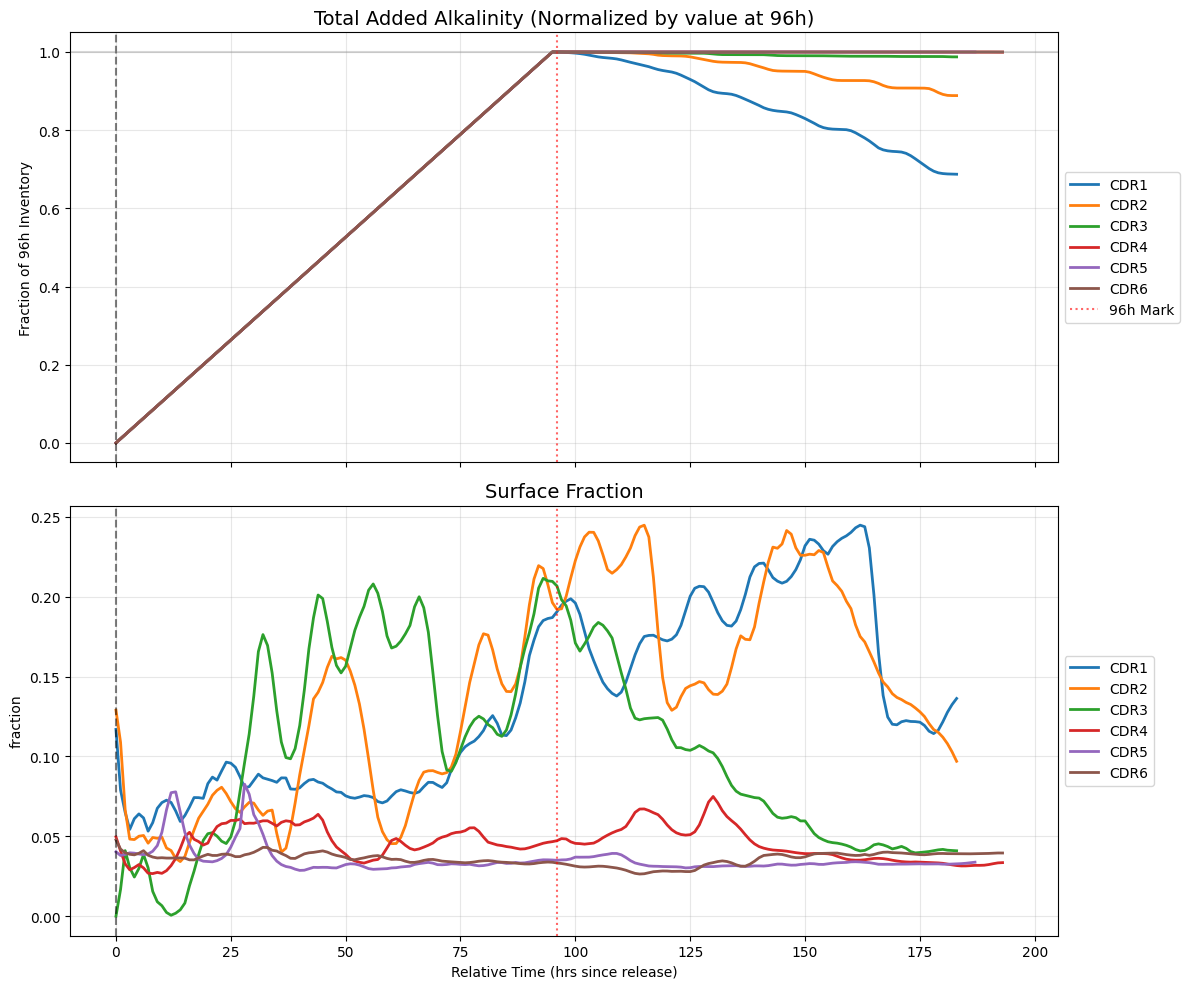

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 1. Load both datasets
ds1 = xr.open_dataset('/home/x-uheede/R/Intermediate_files/Iceland3_total_alk_and_surface_fraction.nc')
ds2 = xr.open_dataset('Iceland3_total_alk_and_surface_fraction_2.nc')

# 2. Merge them into one object
ds = xr.merge([ds1, ds2])

# Define the full range of ensemble members
cdr_members = [f'CDR{i}' for i in range(1, 7)]

# Create the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

print("--- Aligned & Normalized Plot (Normalization at t=96h) ---")

for cdr in cdr_members:
    alk_var = f'total_alk_{cdr}'
    surf_var = f'surface_fraction_{cdr}'
    
    if alk_var in ds:
        # Get values as numpy array
        alk_values = ds[alk_var].values
        
        # Identify index where total_alk is non-NaN and greater than 0
        valid_indices = np.where(~np.isnan(alk_values) & (alk_values > 1e-6))[0]
        
        if len(valid_indices) > 0:
            first_idx = valid_indices[0]
            
            # Create a relative time array starting from 0 at the injection point
            time_rel = ds['time'] - ds['time'].isel(time=first_idx)
            
            # --- NORMALIZATION LOGIC ---
            # 1. Subtract the baseline (value at first_idx) to get "Added Alk"
            alk_added = ds[alk_var] - ds[alk_var].isel(time=first_idx)
            
            # 2. Find the index closest to t=96 in the relative time array
            # .argmin() finds the index of the minimum difference
            idx_96 = np.abs(time_rel - 96).argmin().values
            max_alk_96 = alk_added.isel(time=idx_96).values
            
            # 3. Create the fraction (Total Alk / Alk at 96h)
            alk_fraction = alk_added / max_alk_96
            
            # Mask data before t=0
            alk_plot = alk_fraction.where(time_rel >= 0)
            
            # Plot Total Alk Fraction
            ax1.plot(time_rel, alk_plot, label=f'{cdr}', linewidth=2)
            
            # Plot Surface Fraction (if exists)
            if surf_var in ds:
                surf_plot = ds[surf_var].where(time_rel >= 0)
                ax2.plot(time_rel, surf_plot, label=f'{cdr}', linewidth=2)
                
            print(f"{cdr}: Normalized by {max_alk_96:.2e} mol (value at 96h).")
        else:
            print(f"{cdr}: Contains no values > 0.")
    else:
        print(f"{cdr}: Not found in merged dataset.")

# --- Formatting Top Plot ---
ax1.set_title('Total Added Alkalinity (Normalized by value at 96h)', fontsize=14)
ax1.set_ylabel('Fraction of 96h Inventory')
ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
ax1.axvline(96, color='red', linestyle=':', alpha=0.6, label='96h Mark')
ax1.axhline(1.0, color='gray', linestyle='-', alpha=0.3) # Reference line for 100%
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.grid(True, alpha=0.3)

# --- Formatting Bottom Plot ---
ax2.set_title('Surface Fraction', fontsize=14)
ax2.set_ylabel('fraction')
ax2.set_xlabel('Relative Time (hrs since release)')
ax2.axvline(0, color='black', linestyle='--', alpha=0.5)
ax2.axvline(96, color='red', linestyle=':', alpha=0.6)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.grid(True, alpha=0.3)

ax2.set_xlim(-10, time_rel.max())

plt.tight_layout()
plt.show()

In [1]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
# Load pre-generated CSTAR regridded products for analysis/plotting.
for i in range(1, 7):
    globals()[f"ds_cstar{i}_rg"] = xr.open_dataset(f"ds_cstar{i}_regridded.nc")

print("Loaded ds_cstar*_regridded.nc (CDR1-CDR6) from OAE_ensemble workflow")

Loaded ds_cstar*_regridded.nc (CDR1-CDR6) from OAE_ensemble workflow


In [2]:
from pyproj import Geod
import matplotlib.pyplot as plt

def add_scalebar(ax, length_km, location=(0.1, 0.05), linewidth=3):
    """
    Add a scale bar to a Cartopy map.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Map axes
    length_km : float
        Length of scale bar in kilometers
    location : tuple
        (x_frac, y_frac) position in axes coordinates
    linewidth : int
        Line width
    """

    geod = Geod(ellps="WGS84")

    # Get current map extent in PlateCarree
    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())

    # Starting point
    lon_start = lon_min + location[0] * (lon_max - lon_min)
    lat_start = lat_min + location[1] * (lat_max - lat_min)

    # Compute endpoint using geodesic
    lon_end, lat_end, _ = geod.fwd(
        lon_start, lat_start,
        az=90,              # eastward
        dist=length_km * 1000
    )

    # Draw scale bar
    ax.plot(
        [lon_start, lon_end],
        [lat_start, lat_start],
        transform=ccrs.PlateCarree(),
        color="black",
        linewidth=linewidth
    )

    # Label
    ax.text(
        (lon_start + lon_end) / 2,
        lat_start + 0.002,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="bottom",
        fontsize=9
    )


In [2]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb.
ds_metrics = xr.open_dataset("Iceland3_CDR_extrema_metrics_pt2.nc")

min_pCO2SURF = ds_metrics["min_pCO2SURF_anom"]
max_PH = ds_metrics["max_PH_anom"]
max_ALK = ds_metrics["max_ALK_anom"]
max_ALK_surface = ds_metrics["max_ALK_surface_anom"]
max_DIC = ds_metrics["max_DIC_anom"]

print("Loaded Iceland3_CDR_extrema_metrics.nc")

Loaded Iceland3_CDR_extrema_metrics.nc


In [ ]:
max_DIC.isel(ens=2)

In [4]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
# Load precomputed 0-96 h, 1 m mean fields.
pCO2SURF_mean = xr.open_dataset("Iceland3_pCO2SURF_1m_time0_96_mean_pt2.nc")["__xarray_dataarray_variable__"]
PH_mean = xr.open_dataset("Iceland3_PH_1m_time0_96_mean_pt2.nc")["pH_3D"]
ALK_mean = xr.open_dataset("Iceland3_ALK_1m_time0_96_mean_pt2.nc")["__xarray_dataarray_variable__"]
DIC_mean = xr.open_dataset("Iceland3_DIC_1m_time0_96_mean_pt2.nc")["__xarray_dataarray_variable__"]

print("Loaded precomputed 1m time-mean anomaly fields")

Loaded precomputed 1m time-mean anomaly fields


In [12]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
ds_cstar_metrics = xr.open_dataset("Iceland3_CDR_cstar_cumsum_fields.nc")

FG_cumsum = ds_cstar_metrics["FG_CO2_cumsum_anom"]
hDIC = ds_cstar_metrics["hDIC_anom"]

print("Loaded Iceland3_CDR_cstar_cumsum_fields.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/anvil/projects/x-ees250129/x-uheede/Pub_notebooks/Iceland3_CDR_cstar_cumsum_fields.nc'

In [ ]:
# NetCDF writes moved to OAE_ensemble.ipynb.
# This notebook only consumes already generated products for plotting and diagnostics.

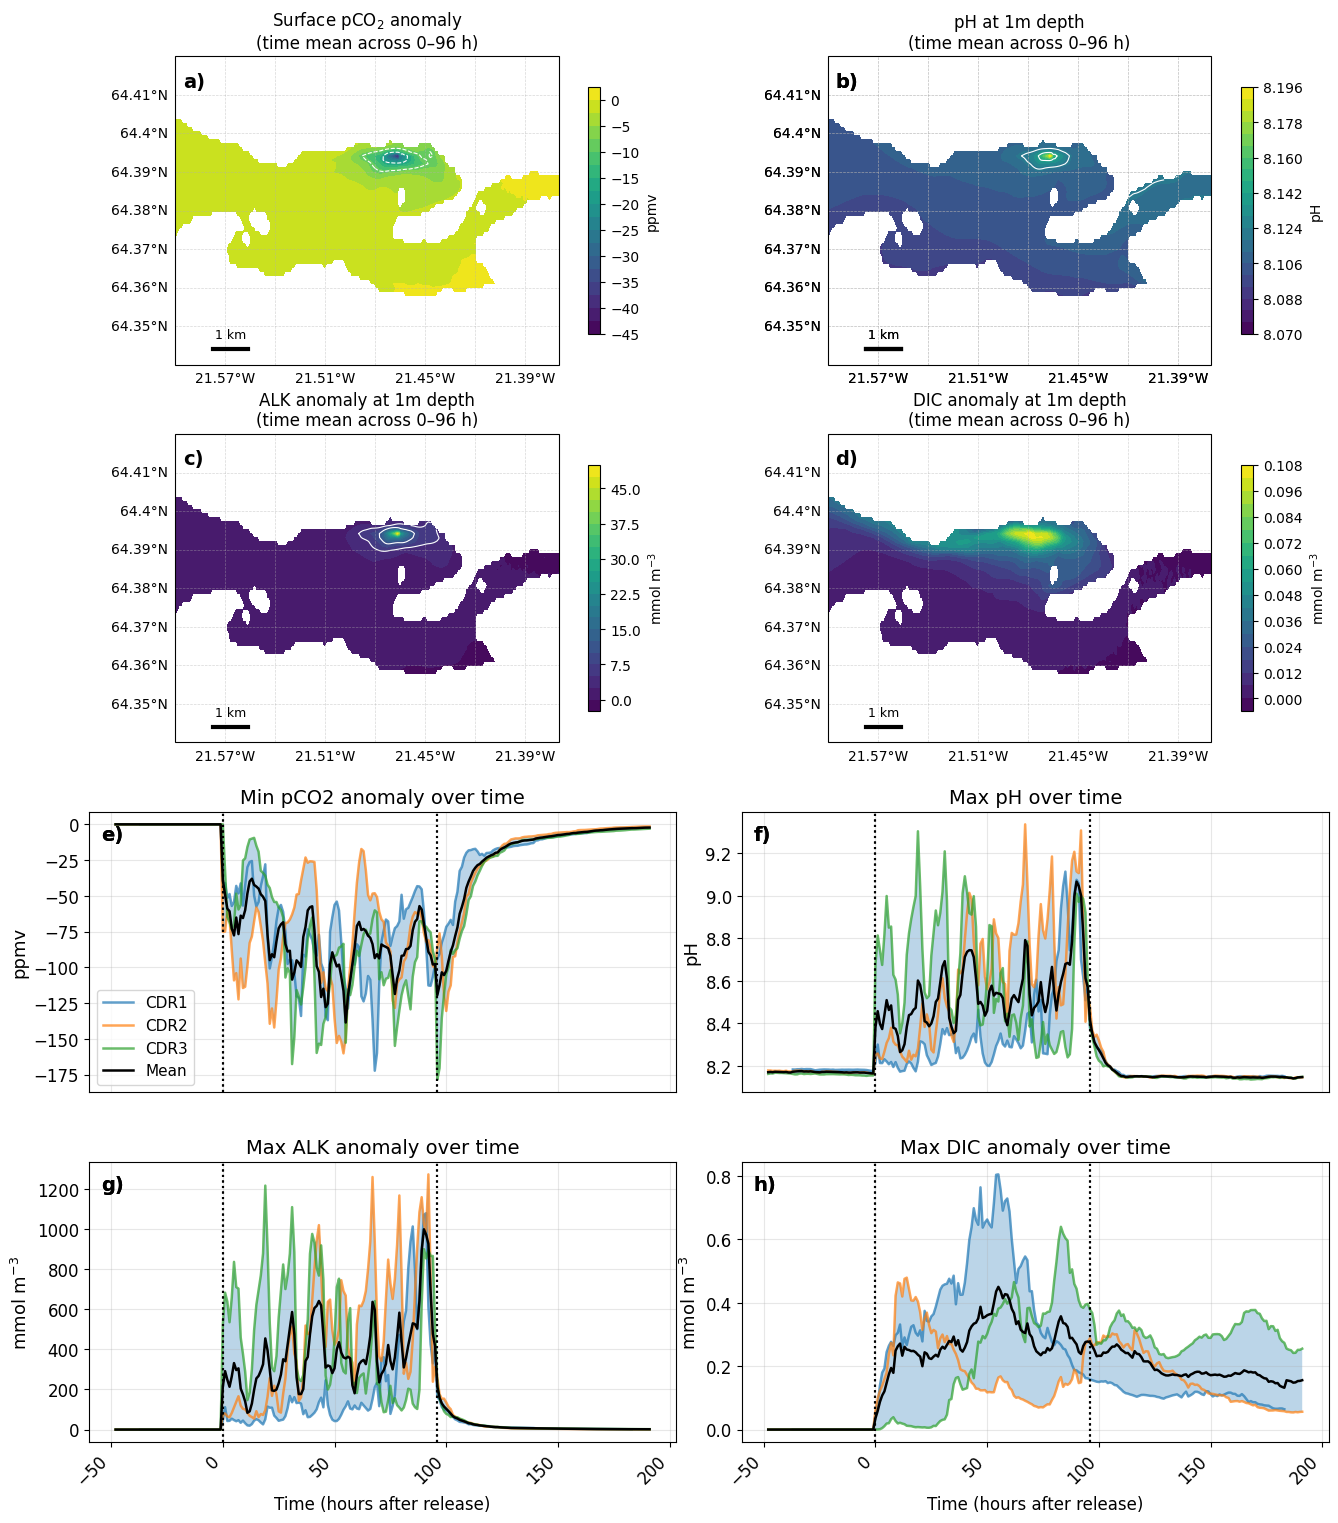

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.Mercator()


# ===============================
# Load NetCDF files
# ===============================

ds_pco2 = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_pCO2SURF_1m_time0_96_mean.nc")
ds_ph   = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_PH_1m_time0_96_mean.nc")
ds_alk  = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_ALK_1m_time0_96_mean.nc")
ds_dic  = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_DIC_1m_time0_96_mean.nc")

ds_metrics = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_CDR_extrema_metrics.nc")
# ===============================
# Extract variables
# ===============================

FG_snapshot = ds_pco2["__xarray_dataarray_variable__"]
pH_surface = ds_ph["pH_3D"]
ALK_anom_surface = ds_alk["__xarray_dataarray_variable__"]
DIC_anom_surface = ds_dic["__xarray_dataarray_variable__"]

FG_min = ds_metrics["min_pCO2SURF_anom"]
pH_max = ds_metrics["max_PH_anom"]
ALK_max = ds_metrics["max_ALK_anom"]
DIC_max = ds_metrics["max_DIC_anom"]

time_rel = ds_metrics.time_rel
time_rel = ds_metrics.time_rel

time_label = "time mean across 0–96 h"

# -------------------------------
# Hvalfjörður extent
# -------------------------------
lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# Convert if grid is 0–360
#if ds_bgc_dia_ens.lon.max() > 180:
lon_min = lon_min % 360
lon_max = lon_max % 360

# ===============================
# Layout (2x2 maps + 2x2 TS)
# ===============================
fig = plt.figure(figsize=(16, 18))

gs = fig.add_gridspec(
    nrows=6,
    ncols=4,
    height_ratios=[3.5, 3.5, 1.2, 1.2, 1.2, 1.2],
    hspace=0.4,
    wspace=0.25
)

ax_c1 = fig.add_subplot(gs[0, 0:2], projection=proj)
ax_c2 = fig.add_subplot(gs[0, 2:4], projection=proj)
ax_c3 = fig.add_subplot(gs[1, 0:2], projection=proj)
ax_c4 = fig.add_subplot(gs[1, 2:4], projection=proj)

ax_ts1 = fig.add_subplot(gs[2:4, 0:2])
ax_ts2 = fig.add_subplot(gs[2:4, 2:4])
ax_ts3 = fig.add_subplot(gs[4:6, 0:2])
ax_ts4 = fig.add_subplot(gs[4:6, 2:4])

panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]

def plot_map(ax, data, title, panel_label,stipple_level=None):

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    mean_field = data.mean("ens")
    std_field = data.std("ens")

    # -----------------------------
    # filled map
    # -----------------------------
    cf = ax.contourf(
        data.lon,
        data.lat,
        mean_field,
        levels=20,
        transform=ccrs.PlateCarree()
    )
    
    # -----------------------------
    # stippled contour
    # -----------------------------
    if stipple_level is not None:
        ax.contour(
            data.lon,
            data.lat,
            mean_field,
            levels=[stipple_level],
            colors="white",
            linewidths=0.8,
            hatches=["-"],
            transform=ccrs.PlateCarree()
        )
        ax.contour(
            data.lon,
            data.lat,
            mean_field,
            levels=[stipple_level*2],
            colors="white",
            linewidths=0.8,
            hatches=["-"],
            transform=ccrs.PlateCarree()
        )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title)

    ax.text(
        0.02,
        0.95,
        panel_label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    add_scalebar(ax, 1)

    return cf
# ===============================
# Map plots
# ===============================

cf1 = plot_map(
    ax_c1,
    FG_snapshot,
    f"Surface pCO$_2$ anomaly\n({time_label})",
    panel_labels[0],
    stipple_level=-9.2   # pCO2
)

cf2 = plot_map(
    ax_c2,
    pH_surface,
    f"pH at 1m depth\n({time_label})",
    panel_labels[1],
    stipple_level=8.12  # pH
)

cf2 = plot_map(
    ax_c2,
    pH_surface,
    f"pH at 1m depth\n({time_label})",
    panel_labels[1],
    stipple_level=8.14# pH
)


cf3 = plot_map(
    ax_c3,
    ALK_anom_surface,
    f"ALK anomaly at 1m depth\n({time_label})",
    panel_labels[2],
    stipple_level=5   # ALK
)

cf4 = plot_map(
    ax_c4,
    DIC_anom_surface,
    f"DIC anomaly at 1m depth\n({time_label})",
    panel_labels[3],
    stipple_level=None  # no detectability contour
)

cb1 = fig.colorbar(cf1, ax=ax_c1, shrink=0.8)
cb1.set_label("ppmv")

cb2 = fig.colorbar(cf2, ax=ax_c2, shrink=0.8)
cb2.set_label("pH")

cb3 = fig.colorbar(cf3, ax=ax_c3, shrink=0.8)
cb3.set_label("mmol m$^{-3}$")

cb4 = fig.colorbar(cf4, ax=ax_c4, shrink=0.8)
cb4.set_label("mmol m$^{-3}$")

# ===============================
# Time series
# ===============================

ts_axes = [ax_ts1, ax_ts2, ax_ts3, ax_ts4]

ts_data = [
    (time_rel, FG_min, "Min pCO2 anomaly", "ppmv"),
    (time_rel, pH_max, "Max pH", "pH"),
    (time_rel, ALK_max, "Max ALK anomaly", "mmol m$^{-3}$"),
    (time_rel, DIC_max, "Max DIC anomaly", "mmol m$^{-3}$")
]
for i, ax in enumerate(ts_axes):

    t, data, ylabel, units = ts_data[i]

    y_min = data.min("ens")
    y_max = data.max("ens")
    y_mean = data.mean("ens")

    # -----------------------
    # ensemble members
    # -----------------------
    for j, ens in enumerate(data.ens.values):
        
        # Only label for first subplot (pCO2)
        if i == 0:
            label = f"CDR{j+1}"
        else:
            label = None

        ax.plot(
            t,
            data.sel(ens=ens),
            linewidth=1.8,
            alpha=0.7,
            label=label
        )

    # -----------------------
    # ensemble spread
    # -----------------------
    ax.fill_between(
        t,
        y_min,
        y_max,
        alpha=0.3
    )

    # -----------------------
    # ensemble mean
    # -----------------------
    ax.plot(
        t,
        y_mean,
        color="black",
        linewidth=1.8,
        label="Mean" if i == 0 else None
    )

    # -----------------------
    # legend ONLY for pCO2
    # -----------------------
    if i == 0:
        ax.legend(fontsize=11)

    ax.set_ylabel(units, fontsize=13)
    ax.set_title(f"{ylabel} over time", fontsize=14)

    ax.tick_params(axis='both', labelsize=12)

    ax.axvline(0, linestyle=":", linewidth=1.5, color="black")
    ax.axvline(96, linestyle=":", linewidth=1.5, color="black")

    ax.grid(True, alpha=0.3)

    ax.text(
        0.02,
        0.95,
        panel_labels[i+4],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_horizontalalignment("right")

    if i in [0, 1]:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", length=0)

    ax.set_ylabel(units, fontsize=13)
    ax.set_title(f"{ylabel} over time", fontsize=14)

    ax.tick_params(axis='both', labelsize=12)

    ax.axvline(0, linestyle=":", linewidth=1.5, color="black")
    ax.axvline(96, linestyle=":", linewidth=1.5, color="black")

    ax.grid(True, alpha=0.3)

    ax.text(
        0.02,
        0.95,
        panel_labels[i+4],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_horizontalalignment("right")

    if i in [0, 1]:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", length=0)
        
# Add x-axis label for bottom row
ax_ts3.set_xlabel("Time (hours after release)",fontsize=12)
ax_ts4.set_xlabel("Time (hours after release)",fontsize=12)
plt.show()

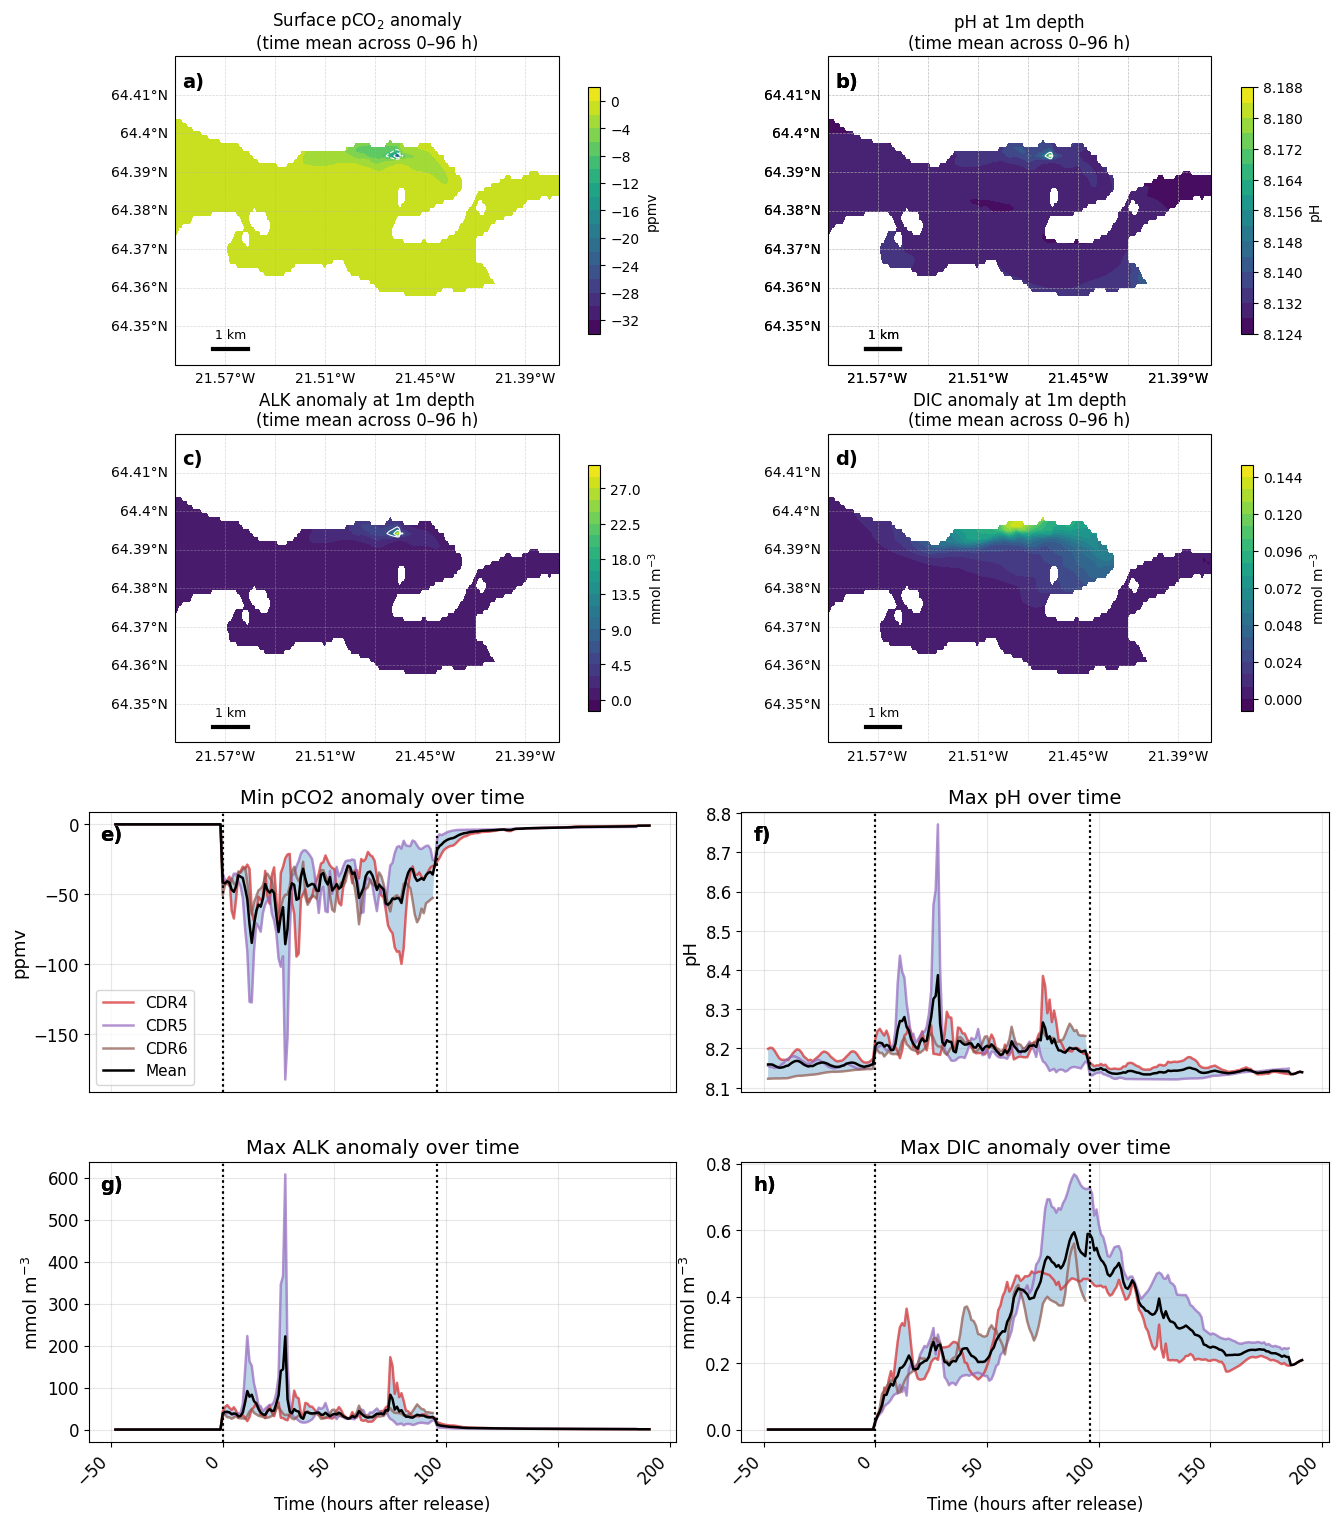

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.Mercator()


# ===============================
# Load NetCDF files
# ===============================

ds_pco2 = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_pCO2SURF_1m_time0_96_mean_pt2.nc")
ds_ph   = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_PH_1m_time0_96_mean_pt2.nc")
ds_alk  = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_ALK_1m_time0_96_mean_pt2.nc")
ds_dic  = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_DIC_1m_time0_96_mean_pt2.nc")

ds_metrics = xr.open_dataset("/home/x-uheede/R/Intermediate_files/Iceland3_CDR_extrema_metrics_pt2.nc")
# ===============================
# Extract variables
# ===============================

FG_snapshot = ds_pco2["__xarray_dataarray_variable__"]
pH_surface = ds_ph["pH_3D"]
ALK_anom_surface = ds_alk["__xarray_dataarray_variable__"]
DIC_anom_surface = ds_dic["__xarray_dataarray_variable__"]

FG_min = ds_metrics["min_pCO2SURF_anom"]
pH_max = ds_metrics["max_PH_anom"]
ALK_max = ds_metrics["max_ALK_anom"]
DIC_max = ds_metrics["max_DIC_anom"]

time_rel = ds_metrics.time_rel
time_rel = ds_metrics.time_rel

time_label = "time mean across 0–96 h"

# -------------------------------
# Hvalfjörður extent
# -------------------------------
lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# Convert if grid is 0–360
#if ds_bgc_dia_ens.lon.max() > 180:
lon_min = lon_min % 360
lon_max = lon_max % 360

# ===============================
# Layout (2x2 maps + 2x2 TS)
# ===============================
fig = plt.figure(figsize=(16, 18))

gs = fig.add_gridspec(
    nrows=6,
    ncols=4,
    height_ratios=[3.5, 3.5, 1.2, 1.2, 1.2, 1.2],
    hspace=0.4,
    wspace=0.25
)

ax_c1 = fig.add_subplot(gs[0, 0:2], projection=proj)
ax_c2 = fig.add_subplot(gs[0, 2:4], projection=proj)
ax_c3 = fig.add_subplot(gs[1, 0:2], projection=proj)
ax_c4 = fig.add_subplot(gs[1, 2:4], projection=proj)

ax_ts1 = fig.add_subplot(gs[2:4, 0:2])
ax_ts2 = fig.add_subplot(gs[2:4, 2:4])
ax_ts3 = fig.add_subplot(gs[4:6, 0:2])
ax_ts4 = fig.add_subplot(gs[4:6, 2:4])

panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]

def plot_map(ax, data, title, panel_label,stipple_level=None):

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    mean_field = data.mean("ens")
    std_field = data.std("ens")

    # -----------------------------
    # filled map
    # -----------------------------
    cf = ax.contourf(
        data.lon,
        data.lat,
        mean_field,
        levels=20,
        transform=ccrs.PlateCarree()
    )
    
    # -----------------------------
    # stippled contour
    # -----------------------------
    if stipple_level is not None:
        ax.contour(
            data.lon,
            data.lat,
            mean_field,
            levels=[stipple_level],
            colors="white",
            linewidths=0.8,
            hatches=["-"],
            transform=ccrs.PlateCarree()
        )
        ax.contour(
            data.lon,
            data.lat,
            mean_field,
            levels=[stipple_level*2],
            colors="white",
            linewidths=0.8,
            hatches=["-"],
            transform=ccrs.PlateCarree()
        )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title)

    ax.text(
        0.02,
        0.95,
        panel_label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    add_scalebar(ax, 1)

    return cf
# ===============================
# Map plots
# ===============================

cf1 = plot_map(
    ax_c1,
    FG_snapshot,
    f"Surface pCO$_2$ anomaly\n({time_label})",
    panel_labels[0],
    stipple_level=-9.2   # pCO2
)

cf2 = plot_map(
    ax_c2,
    pH_surface,
    f"pH at 1m depth\n({time_label})",
    panel_labels[1],
    stipple_level=8.15  # pH
)

cf2 = plot_map(
    ax_c2,
    pH_surface,
    f"pH at 1m depth\n({time_label})",
    panel_labels[1],
    stipple_level=8.18# pH
)


cf3 = plot_map(
    ax_c3,
    ALK_anom_surface,
    f"ALK anomaly at 1m depth\n({time_label})",
    panel_labels[2],
    stipple_level=6.1   # ALK
)

cf4 = plot_map(
    ax_c4,
    DIC_anom_surface,
    f"DIC anomaly at 1m depth\n({time_label})",
    panel_labels[3],
    stipple_level=None  # no detectability contour
)

cb1 = fig.colorbar(cf1, ax=ax_c1, shrink=0.8)
cb1.set_label("ppmv")

cb2 = fig.colorbar(cf2, ax=ax_c2, shrink=0.8)
cb2.set_label("pH")

cb3 = fig.colorbar(cf3, ax=ax_c3, shrink=0.8)
cb3.set_label("mmol m$^{-3}$")

cb4 = fig.colorbar(cf4, ax=ax_c4, shrink=0.8)
cb4.set_label("mmol m$^{-3}$")

# ===============================
# Time series
# ===============================

ts_axes = [ax_ts1, ax_ts2, ax_ts3, ax_ts4]

ts_data = [
    (time_rel, FG_min, "Min pCO2 anomaly", "ppmv"),
    (time_rel, pH_max, "Max pH", "pH"),
    (time_rel, ALK_max, "Max ALK anomaly", "mmol m$^{-3}$"),
    (time_rel, DIC_max, "Max DIC anomaly", "mmol m$^{-3}$")
]
# Get default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n_colors = len(colors)
for i, ax in enumerate(ts_axes):

    t, data, ylabel, units = ts_data[i]

    y_min = data.min("ens")
    y_max = data.max("ens")
    y_mean = data.mean("ens")

    # -----------------------
    # ensemble members
    # -----------------------
    for j, ens in enumerate(data.ens.values):
    # Shift color index by +3
        color = colors[(j + 3) % n_colors]
        
        # Only label for first subplot (pCO2)
        if i == 0:
            label = f"CDR{j+4}"
        else:
            label = None

        ax.plot(
            t,
            data.sel(ens=ens),
            linewidth=1.8,
            alpha=0.7,
            label=label,
            color=color
        )

    # -----------------------
    # ensemble spread
    # -----------------------
    ax.fill_between(
        t,
        y_min,
        y_max,
        alpha=0.3
    )

    # -----------------------
    # ensemble mean
    # -----------------------
    ax.plot(
        t,
        y_mean,
        color="black",
        linewidth=1.8,
        label="Mean" if i == 0 else None
    )

    # -----------------------
    # legend ONLY for pCO2
    # -----------------------
    if i == 0:
        ax.legend(fontsize=11)

    ax.set_ylabel(units, fontsize=13)
    ax.set_title(f"{ylabel} over time", fontsize=14)

    ax.tick_params(axis='both', labelsize=12)

    ax.axvline(0, linestyle=":", linewidth=1.5, color="black")
    ax.axvline(96, linestyle=":", linewidth=1.5, color="black")

    ax.grid(True, alpha=0.3)

    ax.text(
        0.02,
        0.95,
        panel_labels[i+4],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_horizontalalignment("right")

    if i in [0, 1]:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", length=0)

    ax.set_ylabel(units, fontsize=13)
    ax.set_title(f"{ylabel} over time", fontsize=14)

    ax.tick_params(axis='both', labelsize=12)

    ax.axvline(0, linestyle=":", linewidth=1.5, color="black")
    ax.axvline(96, linestyle=":", linewidth=1.5, color="black")

    ax.grid(True, alpha=0.3)

    ax.text(
        0.02,
        0.95,
        panel_labels[i+4],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_horizontalalignment("right")

    if i in [0, 1]:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", length=0)
        
# Add x-axis label for bottom row
ax_ts3.set_xlabel("Time (hours after release)",fontsize=12)
ax_ts4.set_xlabel("Time (hours after release)",fontsize=12)
plt.show()

In [ ]:
FG_min

Plot sum of ALK over time
Slice alk anomly with depth


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import PyCO2SYS as pyco2

max_ALK = ALK_max.mean('ens')+2320 #maximum background alkalinity
# -------------------------------
# 1. Extract max ALK timeseries
# -------------------------------

time = ALK_max['time_rel']

# -------------------------------
# 2. Set background constants
# -------------------------------
BACKGROUND1 = dict(
    ALK = max_ALK+60,     # mmol/m3 
    DIC = 2160.0,     # mmol/m3
    PO4 = 0.3,        ## mmol/m3
    Si = 2,         # mmol/m3
    T = 6.0,
    P = 0,
    S = 33.75,
)

BACKGROUND2 = dict(
    ALK = max_ALK,     # mmol/m3
    DIC = 2110.0,     # mmol/m3
    PO4 = 0.8,        ## mmol/m3
    Si = 6.8,         # mmol/m3
    T = 5,
    P = 0,
    S = 33.75)

import pandas as pd

# -------------------------------
# Collect scenarios
# -------------------------------
scenarios = {"Scenario 1": BACKGROUND1, "Scenario 2": BACKGROUND2}

# -------------------------------
# Build summary table
# -------------------------------
summary_rows = []
for name, params in scenarios.items():
    row = {
        "Scenario": name,
        "ALK (mmol/m3)": params["ALK"].values if isinstance(params["ALK"], xr.DataArray) else params["ALK"],
        "DIC (mmol/m3)": params["DIC"],
        "PO4 (mmol/m3)": params["PO4"],
        "Si (mmol/m3)": params["Si"],
        "T (°C)": params["T"],
        "P (dbar)": params["P"],
        "S (psu)": params["S"]
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df)


     Scenario                                      ALK (mmol/m3)  \
0  Scenario 1  [2380.0, 2380.0, 2380.0, 2380.0, 2380.0, 2380....   
1  Scenario 2  [2320.0, 2320.0, 2320.0, 2320.0, 2320.0, 2320....   

   DIC (mmol/m3)  PO4 (mmol/m3)  Si (mmol/m3)  T (°C)  P (dbar)  S (psu)  
0         2160.0            0.3           2.0     6.0         0    33.75  
1         2110.0            0.8           6.8     5.0         0    33.75  


In [24]:
import numpy as np
import PyCO2SYS as pyco2

def get_csys_with_volumetric_inputs(DATA):
    # --------------------------------
    # 1. Extract values
    # --------------------------------
    alk_vol = np.atleast_1d(DATA["ALK"]).astype(float)
    dic_vol = np.atleast_1d(DATA["DIC"]).astype(float)
    po4_vol = np.atleast_1d(DATA["PO4"]).astype(float)
    si_vol  = np.atleast_1d(DATA["Si"]).astype(float)

    # --------------------------------
    # 2. Clean inputs
    # --------------------------------
    alk_vol[alk_vol < 0] = np.nan
    dic_vol[dic_vol < 0] = np.nan

    # --------------------------------
    # 3. Get density
    # --------------------------------
    temp_results = pyco2.sys(
        par1=alk_vol,
        par2=dic_vol,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"]
    )

    rho = temp_results.get("rho", temp_results.get("density"))

    if rho is None:
        print("Warning: Density not found, using approximate seawater density.")
        rho = 1.026

    # --------------------------------
    # 4. Convert mmol/m3 → µmol/kg
    # --------------------------------
    alk_grav = alk_vol / rho
    dic_grav = dic_vol / rho
    po4_grav = po4_vol / rho
    si_grav  = si_vol / rho

    # --------------------------------
    # 5. Final carbonate system
    # --------------------------------
    results = pyco2.sys(
        par1=alk_grav,
        par2=dic_grav,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"],
        total_phosphate=po4_grav,
        total_silicate=si_grav
    )

    return results


# --------------------------------
# Scenario 1
# --------------------------------
bg1 = get_csys_with_volumetric_inputs(BACKGROUND1)
pH_bg1 = bg1["pH_total"]


# --------------------------------
# Scenario 2
# --------------------------------
bg2 = get_csys_with_volumetric_inputs(BACKGROUND2)
pH_bg2 = bg2["pH_total"]


# --------------------------------
# Print statistics
# --------------------------------
print("\nBACKGROUND 1")
print(f"pH values: {len(pH_bg1)}")
print(f"Average pH: {np.nanmean(pH_bg1):.4f}")


print("\nBACKGROUND 2")
print(f"pH values: {len(pH_bg2)}")
print(f"Average pH: {np.nanmean(pH_bg2):.4f}")



BACKGROUND 1
pH values: 288
Average pH: 8.2253

BACKGROUND 2
pH values: 288
Average pH: 8.2280


In [25]:
import numpy as np
import PyCO2SYS as pyco2

def get_csys_with_volumetric_inputs(DATA):
    # --------------------------------
    # 1. Extract values
    # --------------------------------
    alk_vol = np.atleast_1d(DATA["ALK"]).astype(float)
    dic_vol = np.atleast_1d(DATA["DIC"]).astype(float)
    po4_vol = np.atleast_1d(DATA["PO4"]).astype(float)
    si_vol  = np.atleast_1d(DATA["Si"]).astype(float)

    # --------------------------------
    # 2. Clean inputs
    # --------------------------------
    alk_vol[alk_vol < 0] = np.nan
    dic_vol[dic_vol < 0] = np.nan

    # --------------------------------
    # 3. Get density
    # --------------------------------
    temp_results = pyco2.sys(
        par1=alk_vol,
        par2=dic_vol,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"]
    )

    rho = temp_results.get("rho", temp_results.get("density"))

    if rho is None:
        print("Warning: Density not found, using approximate seawater density.")
        rho = 1.026

    # --------------------------------
    # 4. Convert mmol/m3 → µmol/kg
    # --------------------------------
    alk_grav = alk_vol / rho
    dic_grav = dic_vol / rho
    po4_grav = po4_vol / rho
    si_grav  = si_vol / rho

    # --------------------------------
    # 5. Final carbonate system
    # --------------------------------
    results = pyco2.sys(
        par1=alk_grav,
        par2=dic_grav,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"],
        total_phosphate=po4_grav,
        total_silicate=si_grav
    )

    return results


# --------------------------------
# Scenario 1
# --------------------------------
bg1 = get_csys_with_volumetric_inputs(BACKGROUND1)
pCO2_bg1 = bg1["pCO2"]

# --------------------------------
# Scenario 2
# --------------------------------
bg2 = get_csys_with_volumetric_inputs(BACKGROUND2)
pCO2_bg2 = bg2["pCO2"]

# --------------------------------
# Print statistics
# --------------------------------
print("\nBACKGROUND 1")

print(f"Average pCO2: {np.nanmean(pCO2_bg1):.2f} µatm")

print("\nBACKGROUND 2")

print(f"Average pCO2: {np.nanmean(pCO2_bg2):.2f} µatm")


BACKGROUND 1
Average pCO2: 253.09 µatm

BACKGROUND 2
Average pCO2: 244.45 µatm


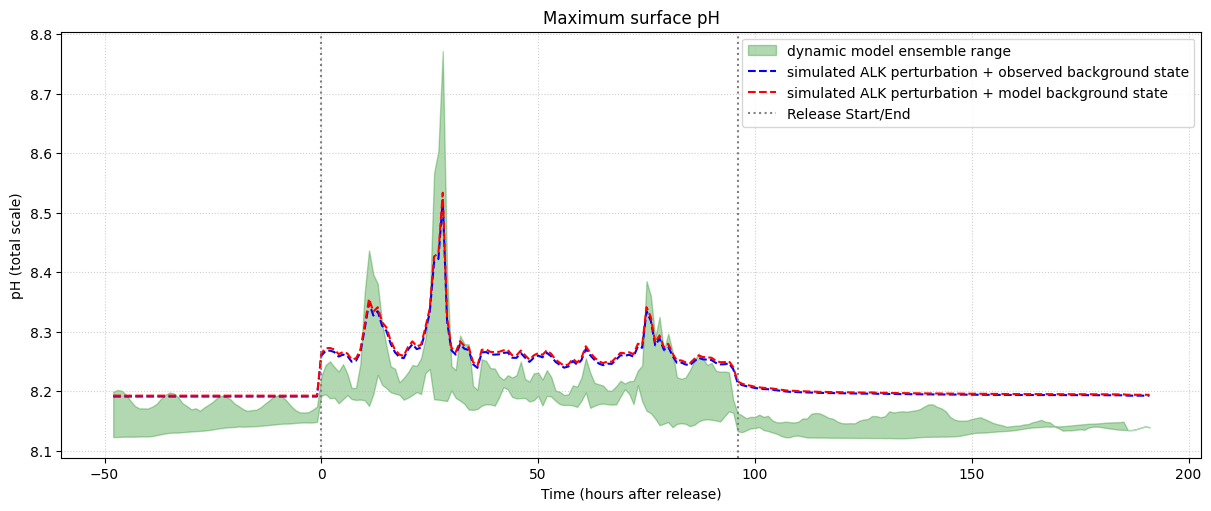

In [26]:
import matplotlib.pyplot as plt
import xarray as xr

# --------------------------------
# pH ensemble spread calculation
# --------------------------------
# Note: This assumes pH_max, pH_bg1, and pH_bg2 are already defined 
# in your workspace from your previous processing steps.
time_pH = pH_max.time_rel

pH_min = pH_max.min(dim="ens")
pH_max_env = pH_max.max(dim="ens")
pH_mean = pH_max.mean(dim="ens")

# --------------------------------
# Figure: Single Panel (Panel A)
# --------------------------------
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

# Plot the ensemble spread (shaded area)
ax.fill_between(
    time_pH,
    pH_min,
    pH_max_env,
    color='green',
    alpha=0.3,
    label='dynamic model ensemble range'
)

# Plot the reference/background states
ax.plot(
    time_pH,
    pH_bg1,
    linestyle='--',
    color='blue',
    label='simulated ALK perturbation + observed background state'
)

ax.plot(
    time_pH,
    pH_bg2,
    linestyle='--',
    color='red',
    label='simulated ALK perturbation + model background state'
)

# Formatting
ax.set_ylabel("pH (total scale)")
ax.set_xlabel("Time (hours after release)")
ax.set_title("Maximum surface pH")
ax.grid(True, linestyle=':', alpha=0.6)

# Release window markers
ax.axvline(0, linestyle=":", color="grey", label='Release Start/End')
ax.axvline(96, linestyle=":", color="grey")

ax.legend(loc='best')

plt.show()

In [ ]:
DIC_vert_int = (DIC_anom * dz_da).sum(dim="depth")
DIC_cum = (DIC_vert_int.isel(time=-1)).load()

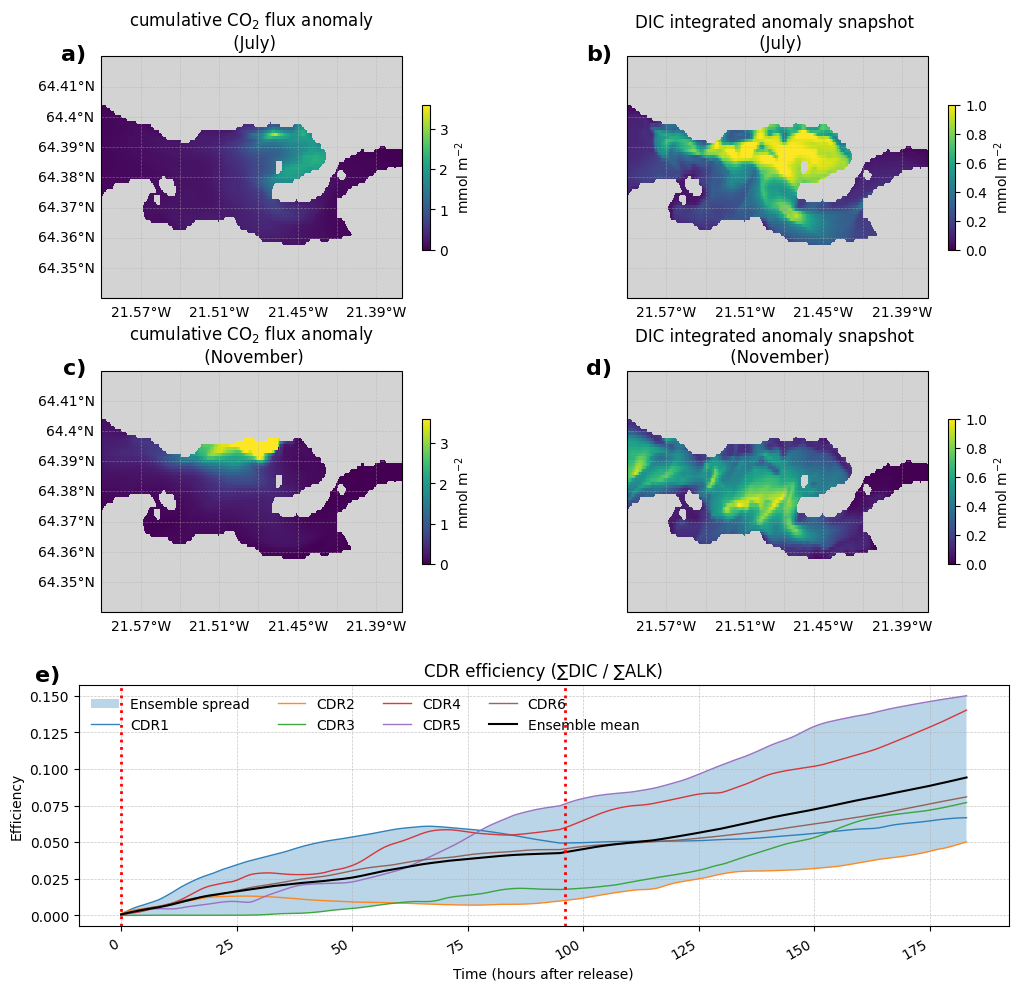

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# =========================
# --- LOAD CDR METRICS ---
# =========================
cdr_paths = {
    "CDR1": "/home/x-uheede/R/Intermediate_files/Iceland3_CDR1_cdr_metrics.nc",
    "CDR2": "/home/x-uheede/R/Intermediate_files/Iceland3_CDR2_cdr_metrics.nc",
    "CDR3": "/home/x-uheede/R/Intermediate_files/Iceland3_CDR3_cdr_metrics.nc",
    "CDR4": "/home/x-uheede/R/Intermediate_files/Iceland3_CDR4_cdr_metrics.nc",
    "CDR5": "/home/x-uheede/R/Intermediate_files/Iceland3_CDR5_cdr_metrics.nc",
    "CDR6": "/home/x-uheede/R/Intermediate_files/Iceland3_CDR6_cdr_metrics.nc",
}

cstar_paths = {
    "CDR1": "/home/x-uheede/R/Intermediate_files/ds_cstar1_regridded.nc",
    "CDR2": "/home/x-uheede/R/Intermediate_files/ds_cstar2_regridded.nc",
    "CDR3": "/home/x-uheede/R/Intermediate_files/ds_cstar3_regridded.nc",
    "CDR4": "/home/x-uheede/R/Intermediate_files/ds_cstar4_regridded.nc",
    "CDR5": "/home/x-uheede/R/Intermediate_files/ds_cstar5_regridded.nc",
    "CDR6": "/home/x-uheede/R/Intermediate_files/ds_cstar6_regridded.nc",
}
cdr_datasets = {ens: xr.open_dataset(path) for ens, path in cdr_paths.items()}

eff_rel_list = []

for ens in cdr_paths.keys():
    ds = xr.open_dataset(cdr_paths[ens])
    eff = ds["cdr_efficiency"]

    first_valid_index = np.where(np.isfinite(eff.values))[0][0]
    time_rel = np.arange(len(eff)) - first_valid_index

    eff_rel = eff.assign_coords(time_rel=("time", time_rel))
    eff_rel = eff_rel.swap_dims({"time": "time_rel"}).drop_vars("time")

    eff_rel_list.append(eff_rel)

common_time_rel = np.arange(
    max(e.time_rel.min().item() for e in eff_rel_list),
    min(e.time_rel.max().item() for e in eff_rel_list) + 1
)

eff_aligned = [e.sel(time_rel=common_time_rel) for e in eff_rel_list]

eff_stack = xr.concat(eff_aligned, dim="ens")
eff_stack["ens"] = list(cdr_paths.keys())

eff_mean = eff_stack.mean("ens")
eff_min = eff_stack.min("ens")
eff_max = eff_stack.max("ens")

time_rel = eff_mean.time_rel

cstar_datasets = {ens: xr.open_dataset(path) for ens, path in cstar_paths.items()}

fg_list = []
dic_list = []

groups = {
    "g1": ["CDR1", "CDR2", "CDR3"],
    "g2": ["CDR4", "CDR5", "CDR6"],
}

FG_maps = {}
DIC_maps = {}

for g, members in groups.items():

    fg_list = []
    dic_list = []

    for ens in members:
        ds = xr.open_dataset(cstar_paths[ens])

        FG = ds["FG_CO2"] - ds["FG_ALT_CO2"]
        FG_cumsum = FG.cumsum("time") * 3600

        DIC = ds["hDIC_sum"] - ds["hDIC_ALT_CO2_sum"]

        fg_list.append(FG_cumsum)
        dic_list.append(DIC)

    FG_maps[g] = xr.concat(fg_list, dim="ens").mean("ens").isel(time=-1)
    DIC_maps[g] = xr.concat(dic_list, dim="ens").mean("ens").isel(time=-1)

lon = FG_maps["g1"]["lon"]
lat = FG_maps["g1"]["lat"]
land_mask = (FG_maps["g1"] == 0)

# =========================
# --- ENSEMBLE MEAN MAPS ---
# =========================
FG_stack = xr.concat(fg_list, dim="ens")
DIC_stack = xr.concat(dic_list, dim="ens")

FG_mean = FG_stack.mean("ens").isel(time=-1)
DIC_mean = DIC_stack.mean("ens").isel(time=-1)

lon = FG_mean["lon"]
lat = FG_mean["lat"]

land_mask = (FG_mean == 0)

# =========================
# --- FIGURE LAYOUT ---
# =========================
fig = plt.figure(figsize=(12, 10))

gs = gridspec.GridSpec(
    nrows=3,
    ncols=2,
    height_ratios=[1, 1, 1],
    hspace=0.30,   # was 0.12
    wspace=0.30    # was 0.15
)

proj = ccrs.Mercator()
pc = ccrs.PlateCarree()
def plot_map(ax, data, title, label, letter, vmin=None, vmax=None, show_lat_labels=True):

    ax.set_title(title, fontsize=12)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pc)

    ax.contourf(
        lon,
        lat,
        land_mask,
        levels=[0.5, 1.5],
        colors=["lightgrey"],
        transform=pc,
        zorder=2
    )

    im = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=pc,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=1
    )

    gl = ax.gridlines(
        crs=pc,
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_lat_labels
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    cb = plt.colorbar(im, ax=ax, shrink=0.6)
    cb.set_label(label)

    ax.text(
        -0.05,
        1.05,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )
# =========================   
# --- FG_CO2 MAP ---
# =========================
ax_map1 = fig.add_subplot(gs[0, 0], projection=proj)
plot_map(ax_map1, FG_maps["g1"],
         "cumulative CO$_2$ flux anomaly \n (July)", "mmol m$^{-2}$", "a)", vmin=0, vmax=0.001*3600)

ax_map2 = fig.add_subplot(gs[0, 1], projection=proj)
plot_map(ax_map2, DIC_maps["g1"],
         "DIC integrated anomaly snapshot \n (July)", "mmol m$^{-2}$", "b)",
         vmin=0, vmax=1, show_lat_labels=False)

ax_map3 = fig.add_subplot(gs[1, 0], projection=proj)
plot_map(ax_map3, FG_maps["g2"],
         "cumulative CO$_2$ flux anomaly \n (November)", "mmol m$^{-2}$", "c)", vmin=0, vmax=0.001*3600)

ax_map4 = fig.add_subplot(gs[1, 1], projection=proj)
plot_map(ax_map4, DIC_maps["g2"],
         "DIC integrated anomaly snapshot \n (November)", "mmol m$^{-2}$", "d)",
         vmin=0, vmax=1, show_lat_labels=False)

# =========================
# --- TIME SERIES ---
# =========================

ax_ts = fig.add_subplot(gs[2, :])
# --- ensemble spread ---
ax_ts.fill_between(
    time_rel,
    eff_min.values,
    eff_max.values,
    alpha=0.3,
    label="Ensemble spread"
)

# --- individual ensemble members (thin lines) ---
for ens in eff_stack.ens.values:
    ax_ts.plot(
        time_rel,
        eff_stack.sel(ens=ens).values,
        linewidth=1,
        alpha=0.9,
        linestyle="-",
        label=f"{ens}"
    )

# --- ensemble mean ---
ax_ts.plot(
    time_rel,
    eff_mean.values,
    linewidth=1.5,
    color="black",
    label="Ensemble mean"
)

# --- red stippled vertical lines at 0 and 96 hrs ---
for t in [0, 96]:
    ax_ts.axvline(
        x=t,
        color="red",
        linestyle=":",
        linewidth=2
    )

ax_ts.set_title("CDR efficiency (∑DIC / ∑ALK)")
ax_ts.set_xlabel("Time (hours after release)")
ax_ts.set_ylabel("Efficiency")

ax_ts.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# cleaner legend
ax_ts.legend(ncol=4, frameon=False)

ax_ts.text(
    -0.02,
    1.08,
    "e)",
    transform=ax_ts.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top',
    ha='right'
)
plt.setp(ax_ts.get_xticklabels(), rotation=30, ha="right")

plt.subplots_adjust(top=0.95, bottom=0.08)

plt.show()

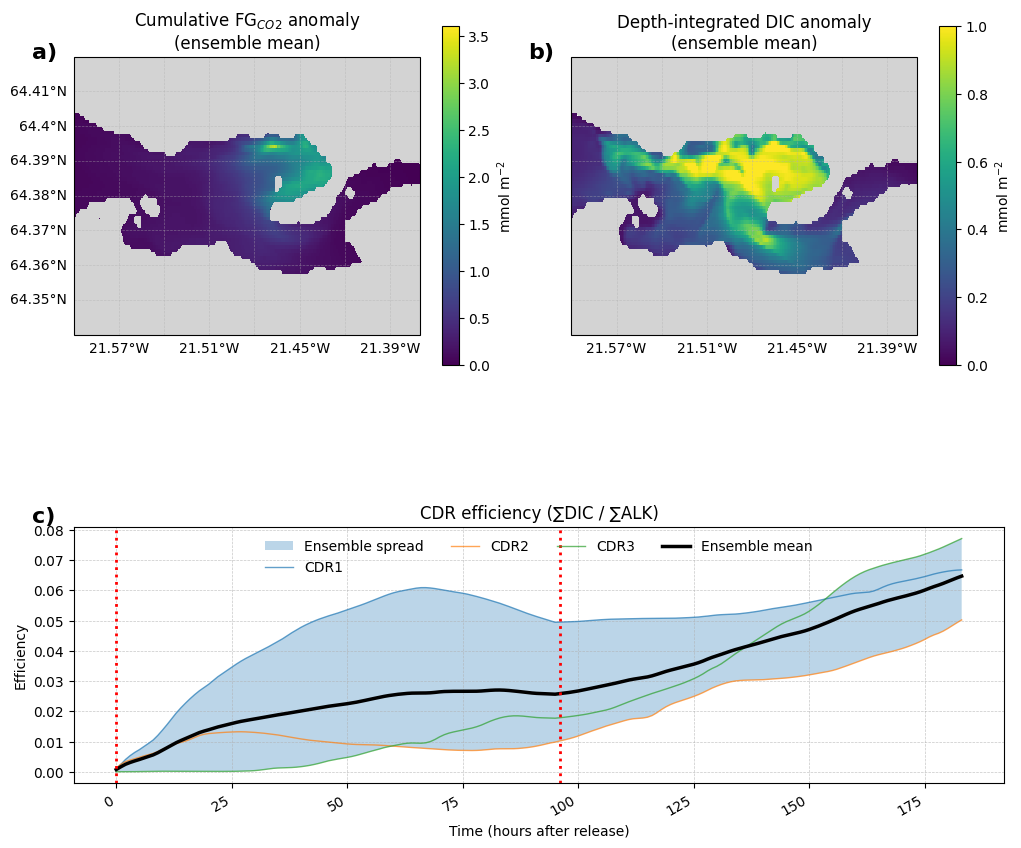

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# =========================
# --- LOAD CDR METRICS ---
# =========================
cdr_paths = {
    "CDR1": "Iceland3_CDR1_cdr_metrics.nc",
    "CDR2": "Iceland3_CDR2_cdr_metrics.nc",
    "CDR3": "Iceland3_CDR3_cdr_metrics.nc",
}

cdr_datasets = {ens: xr.open_dataset(path) for ens, path in cdr_paths.items()}

eff_rel_list = []

for ens in ["CDR1", "CDR2", "CDR3"]:

    ds = cdr_datasets[ens]
    eff = ds["cdr_efficiency"]

    first_valid_index = np.where(np.isfinite(eff.values))[0][0]

    time_rel = np.arange(len(eff)) - first_valid_index

    eff_rel = eff.assign_coords(time_rel=("time", time_rel))
    eff_rel = eff_rel.swap_dims({"time": "time_rel"})
    eff_rel = eff_rel.drop_vars("time")

    eff_rel_list.append(eff_rel)

common_time_rel = np.arange(
    max(e.time_rel.min().item() for e in eff_rel_list),
    min(e.time_rel.max().item() for e in eff_rel_list) + 1
)

eff_aligned = [e.sel(time_rel=common_time_rel) for e in eff_rel_list]

eff_stack = xr.concat(eff_aligned, dim="ens")
eff_stack["ens"] = ["CDR1", "CDR2", "CDR3"]

eff_mean = eff_stack.mean("ens", skipna=True)
eff_min = eff_stack.min("ens", skipna=True)
eff_max = eff_stack.max("ens", skipna=True)

time_rel = eff_mean.time_rel


# =========================
# --- LOAD NEW CSTAR FILES ---
# =========================
cstar_paths = {
    "CDR1": "/anvil/projects/x-ees250129/x-uheede/Intermediate_files/ds_cstar1_regridded.nc",
    "CDR2": "/anvil/projects/x-ees250129/x-uheede/Intermediate_files/ds_cstar2_regridded.nc",
    "CDR3": "/anvil/projects/x-ees250129/x-uheede/Intermediate_files/ds_cstar3_regridded.nc",
}

cstar_datasets = {ens: xr.open_dataset(path) for ens, path in cstar_paths.items()}

fg_list = []
dic_list = []

for ens in ["CDR1", "CDR2", "CDR3"]:

    ds = cstar_datasets[ens]

    # --- FG cumulative anomaly ---
    FG = ds["FG_CO2"]-ds["FG_ALT_CO2"]
    FG_anom = FG
    FG_cumsum = FG_anom.cumsum("time")*3600

    # --- DIC cumulative anomaly ---
    DIC = ds["hDIC_sum"]-ds["hDIC_ALT_CO2_sum"]
    DIC_anom = DIC
    DIC_cumsum = DIC_anom
    DIC_int = DIC_cumsum

    fg_list.append(FG_cumsum)
    dic_list.append(DIC_int)


# =========================
# --- ENSEMBLE MEAN MAPS ---
# =========================
FG_stack = xr.concat(fg_list, dim="ens")
DIC_stack = xr.concat(dic_list, dim="ens")

FG_mean = FG_stack.mean("ens").isel(time=-1)
DIC_mean = DIC_stack.mean("ens").isel(time=-1)

lon = FG_mean["lon"]
lat = FG_mean["lat"]

land_mask = (FG_mean == 0)

# =========================
# --- FIGURE LAYOUT ---
# =========================
fig = plt.figure(figsize=(12, 10))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[2.2, 1],
    hspace=0.12,   # reduced from 0.25
    wspace=0.15
)

proj = ccrs.Mercator()
pc = ccrs.PlateCarree()
def plot_map(ax, data, title, label, letter, vmin=None, vmax=None, show_lat_labels=True):

    ax.set_title(title, fontsize=12)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pc)

    ax.contourf(
        lon,
        lat,
        land_mask,
        levels=[0.5, 1.5],
        colors=["lightgrey"],
        transform=pc,
        zorder=2
    )

    im = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=pc,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=1
    )

    gl = ax.gridlines(
        crs=pc,
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_lat_labels
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    cb = plt.colorbar(im, ax=ax, shrink=0.6)
    cb.set_label(label)

    ax.text(
        -0.05,
        1.05,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )
# =========================   
# --- FG_CO2 MAP ---
# =========================
ax_map1 = fig.add_subplot(gs[0, 0], projection=proj)

plot_map(
    ax_map1,
    FG_mean,
    "Cumulative FG$_{CO2}$ anomaly\n(ensemble mean)",
    "mmol m$^{-2}$",
    "a)",
    vmin=0,
    vmax=0.001*3600
)


# =========================
# --- DIC MAP ---
# =========================
ax_map2 = fig.add_subplot(gs[0, 1], projection=proj)

plot_map(
    ax_map2,
    DIC_mean,
    "Depth-integrated DIC anomaly\n(ensemble mean)",
    "mmol m$^{-2}$",
    "b)",
    vmin=0,
    vmax=1,
    show_lat_labels=False
)
# =========================
# --- TIME SERIES ---
# =========================
ax_ts = fig.add_subplot(gs[1, :])

# --- ensemble spread ---
ax_ts.fill_between(
    time_rel,
    eff_min.values,
    eff_max.values,
    alpha=0.3,
    label="Ensemble spread"
)

# --- individual ensemble members (thin lines) ---
for ens in eff_stack.ens.values:
    ax_ts.plot(
        time_rel,
        eff_stack.sel(ens=ens).values,
        linewidth=1,
        alpha=0.7,
        linestyle="-",
        label=f"{ens}"
    )

# --- ensemble mean ---
ax_ts.plot(
    time_rel,
    eff_mean.values,
    linewidth=2.5,
    color="black",
    label="Ensemble mean"
)

# --- red stippled vertical lines at 0 and 96 hrs ---
for t in [0, 96]:
    ax_ts.axvline(
        x=t,
        color="red",
        linestyle=":",
        linewidth=2
    )

ax_ts.set_title("CDR efficiency (∑DIC / ∑ALK)")
ax_ts.set_xlabel("Time (hours after release)")
ax_ts.set_ylabel("Efficiency")

ax_ts.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# cleaner legend
ax_ts.legend(ncol=4, frameon=False)

ax_ts.text(
    -0.02,
    1.08,
    "c)",
    transform=ax_ts.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top',
    ha='right'
)
plt.setp(ax_ts.get_xticklabels(), rotation=30, ha="right")

plt.subplots_adjust(top=0.95, bottom=0.08)

plt.show()